# Potential Problems in linear regression
This notebook discusses potential limitations and problems of linear regressions in machine learning. Three potential issues and their solutions are discussed, accompanied with A.I. generated code showing these examples of the problems. Claude was the generative A.I. used for this assignment and was provided specified data issue and the following prompt:
"Write Python code that: 

- generates synthetic data that clearly illustrates the issue
- produces plots making the issue visually clear
- where applicable, produces additional plots showing how the issue can be addressed"


## Non-linearity of the data
A big problem with a linear regression is that the model assumes the relationship between the predictor and response variable is linear. Fitting the wrong power to a model will result in over and under predicting y values. A way to detect this is by plotting the residuals and looking for a non-linear pattern.

**Question:** How are we able to tell if the model is poorly fit (i.e. using a linear regression for a non-linear relationship) vs. when the predictor variable is just not a good indicator of the response variable?
**Invesitgated answer:** Often times when the predictor is not representative of the response variable, there is no recognizable pattern. If it was just a poorly fit model, there are transformations that can be done on the data that would eventually show a pattern.

### Code displaying non-linearity from Claude

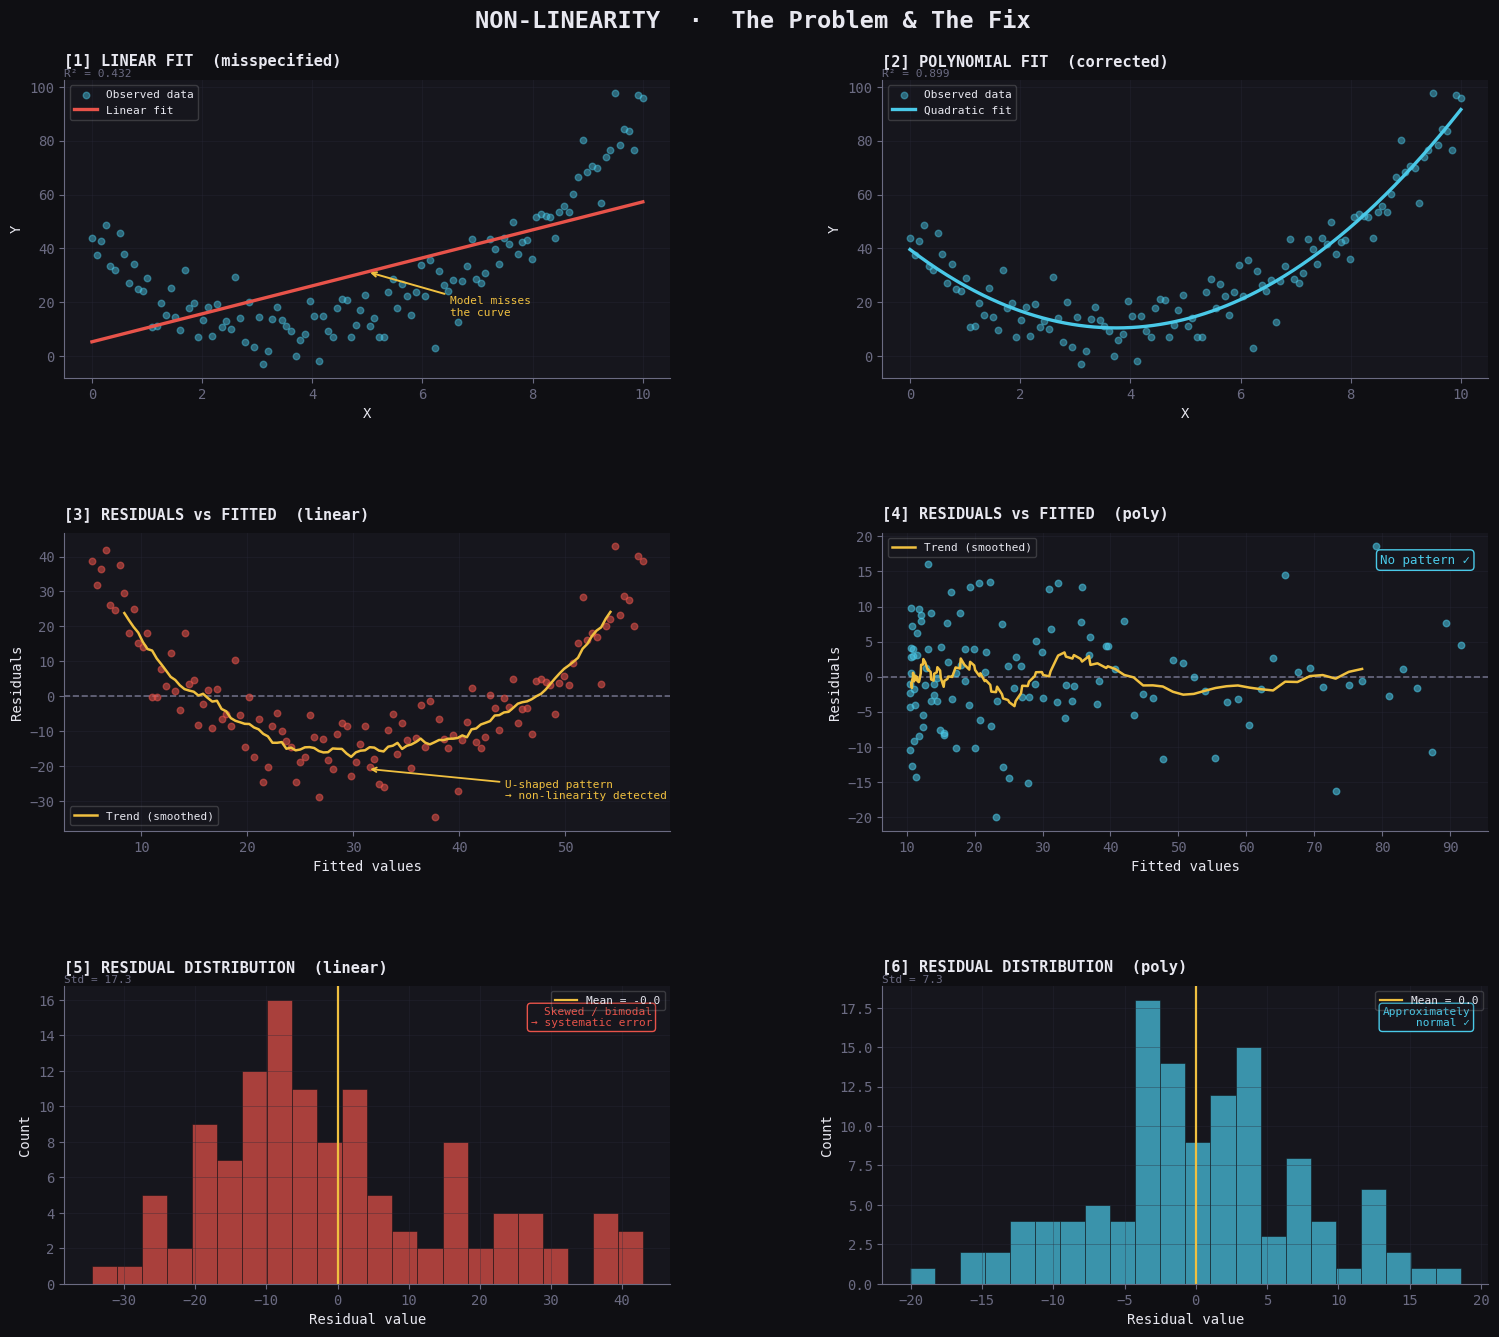

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

np.random.seed(42)

# ── Palette ──────────────────────────────────────────────────────────────────
BG      = "#0f0f13"
PANEL   = "#16161d"
ACCENT1 = "#e8534a"   # red   – linear (bad)
ACCENT2 = "#4ac9e8"   # cyan  – data / poly (good)
ACCENT3 = "#f0c040"   # gold  – residuals / highlights
TEXT    = "#e8e8f0"
MUTED   = "#6b6b82"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    MUTED,
    "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        TEXT,
    "grid.color":        "#2a2a38",
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Synthetic data: quadratic truth + noise ───────────────────────────────
n   = 120
X   = np.linspace(0, 10, n)
Y   = 2 * X**2 - 15 * X + 40 + np.random.normal(0, 8, n)
X2d = X.reshape(-1, 1)

# ── Fit models ────────────────────────────────────────────────────────────
lin  = LinearRegression().fit(X2d, Y)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X2d, Y)

Xplot   = np.linspace(0, 10, 300).reshape(-1, 1)
Y_lin   = lin.predict(Xplot)
Y_poly  = poly.predict(Xplot)

resid_lin  = Y - lin.predict(X2d)
resid_poly = Y - poly.predict(X2d)
yhat_lin   = lin.predict(X2d)
yhat_poly  = poly.predict(X2d)

r2_lin  = r2_score(Y, lin.predict(X2d))
r2_poly = r2_score(Y, poly.predict(X2d))

# ── Figure layout ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14), facecolor=BG)
fig.suptitle(
    "NON-LINEARITY  ·  The Problem & The Fix",
    fontsize=17, fontweight="bold", color=TEXT,
    y=0.97
)

gs  = gridspec.GridSpec(3, 2, figure=fig,
                         hspace=0.52, wspace=0.35,
                         left=0.07, right=0.96,
                         top=0.92, bottom=0.06)

ax1 = fig.add_subplot(gs[0, 0])   # data + linear fit
ax2 = fig.add_subplot(gs[0, 1])   # data + poly fit
ax3 = fig.add_subplot(gs[1, 0])   # residuals – linear  (vs fitted)
ax4 = fig.add_subplot(gs[1, 1])   # residuals – poly    (vs fitted)
ax5 = fig.add_subplot(gs[2, 0])   # residuals – linear  (histogram)
ax6 = fig.add_subplot(gs[2, 1])   # residuals – poly    (histogram)

def style_ax(ax, title, subtitle=""):
    ax.set_title(title, fontsize=11, fontweight="bold",
                 color=TEXT, pad=10, loc="left")
    if subtitle:
        ax.text(0.0, 1.01, subtitle, transform=ax.transAxes,
                fontsize=8, color=MUTED)
    ax.grid(True, alpha=0.4)

# ── Row 1: Scatter + fits ─────────────────────────────────────────────────
for ax, fit_Y, color, label, r2, title in [
    (ax1, Y_lin,  ACCENT1, "Linear fit",    r2_lin,  "[1] LINEAR FIT  (misspecified)"),
    (ax2, Y_poly, ACCENT2, "Quadratic fit", r2_poly, "[2] POLYNOMIAL FIT  (corrected)"),
]:
    ax.scatter(X, Y, s=22, color=ACCENT2, alpha=0.45, zorder=2, label="Observed data")
    ax.plot(Xplot.ravel(), fit_Y, color=color, lw=2.4, zorder=3, label=label)
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.legend(fontsize=8, framealpha=0.2)
    style_ax(ax, title, f"R² = {r2:.3f}")

# annotation: arch on linear
ax1.annotate("Model misses\nthe curve",
             xy=(5, lin.predict([[5]])[0]),
             xytext=(6.5, 15),
             arrowprops=dict(arrowstyle="->", color=ACCENT3, lw=1.4),
             fontsize=8, color=ACCENT3)

# ── Row 2: Residual vs Fitted ─────────────────────────────────────────────
for ax, yhat, resid, color, title in [
    (ax3, yhat_lin,  resid_lin,  ACCENT1, "[3] RESIDUALS vs FITTED  (linear)"),
    (ax4, yhat_poly, resid_poly, ACCENT2, "[4] RESIDUALS vs FITTED  (poly)"),
]:
    ax.axhline(0, color=MUTED, lw=1.2, ls="--")
    ax.scatter(yhat, resid, s=22, color=color, alpha=0.55, zorder=2)
    # smoothed trend
    order   = np.argsort(yhat)
    smooth  = np.convolve(resid[order], np.ones(15)/15, mode="valid")
    xsmooth = yhat[order][7:-7]
    ax.plot(xsmooth, smooth, color=ACCENT3, lw=1.8, label="Trend (smoothed)")
    ax.set_xlabel("Fitted values"); ax.set_ylabel("Residuals")
    ax.legend(fontsize=8, framealpha=0.2)
    style_ax(ax, title)

ax3.annotate("U-shaped pattern\n→ non-linearity detected",
             xy=(np.median(yhat_lin), np.min(resid_lin)*0.6),
             xytext=(np.percentile(yhat_lin, 75), np.min(resid_lin)*0.85),
             arrowprops=dict(arrowstyle="->", color=ACCENT3, lw=1.3),
             fontsize=8, color=ACCENT3)

ax4.text(0.97, 0.93, "No pattern ✓",
         transform=ax4.transAxes, ha="right", va="top",
         fontsize=9, color=ACCENT2,
         bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL, edgecolor=ACCENT2))

# ── Row 3: Residual histograms ────────────────────────────────────────────
for ax, resid, color, title in [
    (ax5, resid_lin,  ACCENT1, "[5] RESIDUAL DISTRIBUTION  (linear)"),
    (ax6, resid_poly, ACCENT2, "[6] RESIDUAL DISTRIBUTION  (poly)"),
]:
    ax.hist(resid, bins=22, color=color, alpha=0.7, edgecolor=BG, linewidth=0.5)
    ax.axvline(resid.mean(), color=ACCENT3, lw=1.6,
               label=f"Mean = {resid.mean():.1f}")
    ax.set_xlabel("Residual value"); ax.set_ylabel("Count")
    ax.legend(fontsize=8, framealpha=0.2)
    style_ax(ax, title, f"Std = {resid.std():.1f}")

ax5.text(0.97, 0.93, "Skewed / bimodal\n→ systematic error",
         transform=ax5.transAxes, ha="right", va="top",
         fontsize=8, color=ACCENT1,
         bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL, edgecolor=ACCENT1))

ax6.text(0.97, 0.93, "Approximately\nnormal ✓",
         transform=ax6.transAxes, ha="right", va="top",
         fontsize=8, color=ACCENT2,
         bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL, edgecolor=ACCENT2))

out = "/mnt/user-data/outputs/nonlinearity_demo.png"
plt.show() # I added this to actually display the plots rather than save them as a PNG like Claude did

Non-linear data plots show a clearly non-linear data relationship compared to a linear relationship. Residuals are plotted as well, which is a good indicator if non-linear data is fitted to a linear regression.

## Outliers
Another issue with linear regression is the possibility of outliers. This occurs when the y value is vastly different from the expected y values for a given X value. This occurs by random chance and is often represented in stats as the tail ends of a distribution curve. However, a linear regression model cannot account for the randomness of outliers, which results in a worse fit of the model. These can be spotted by plotting the residuals or visualizing the data in a simple x~y plot. Occasionally, outliers occur due to mistakes in data entry or processing, so identifying them is important in ensuring data is truly representative. 

**Question:** When is it right to remove rather than scale response variable? There seems like a lack of integrity by removing outliers that don't necessarily make sense, but what would be exceptions to that?
**Investigated answer:** It seems like this decision is at the discretion of the data scientist. There are times when data should be removes (entry error) and times when scaling is better (extreme but true values). Overall data should not be removed for convience. 

### Code displaying outliers from Claude

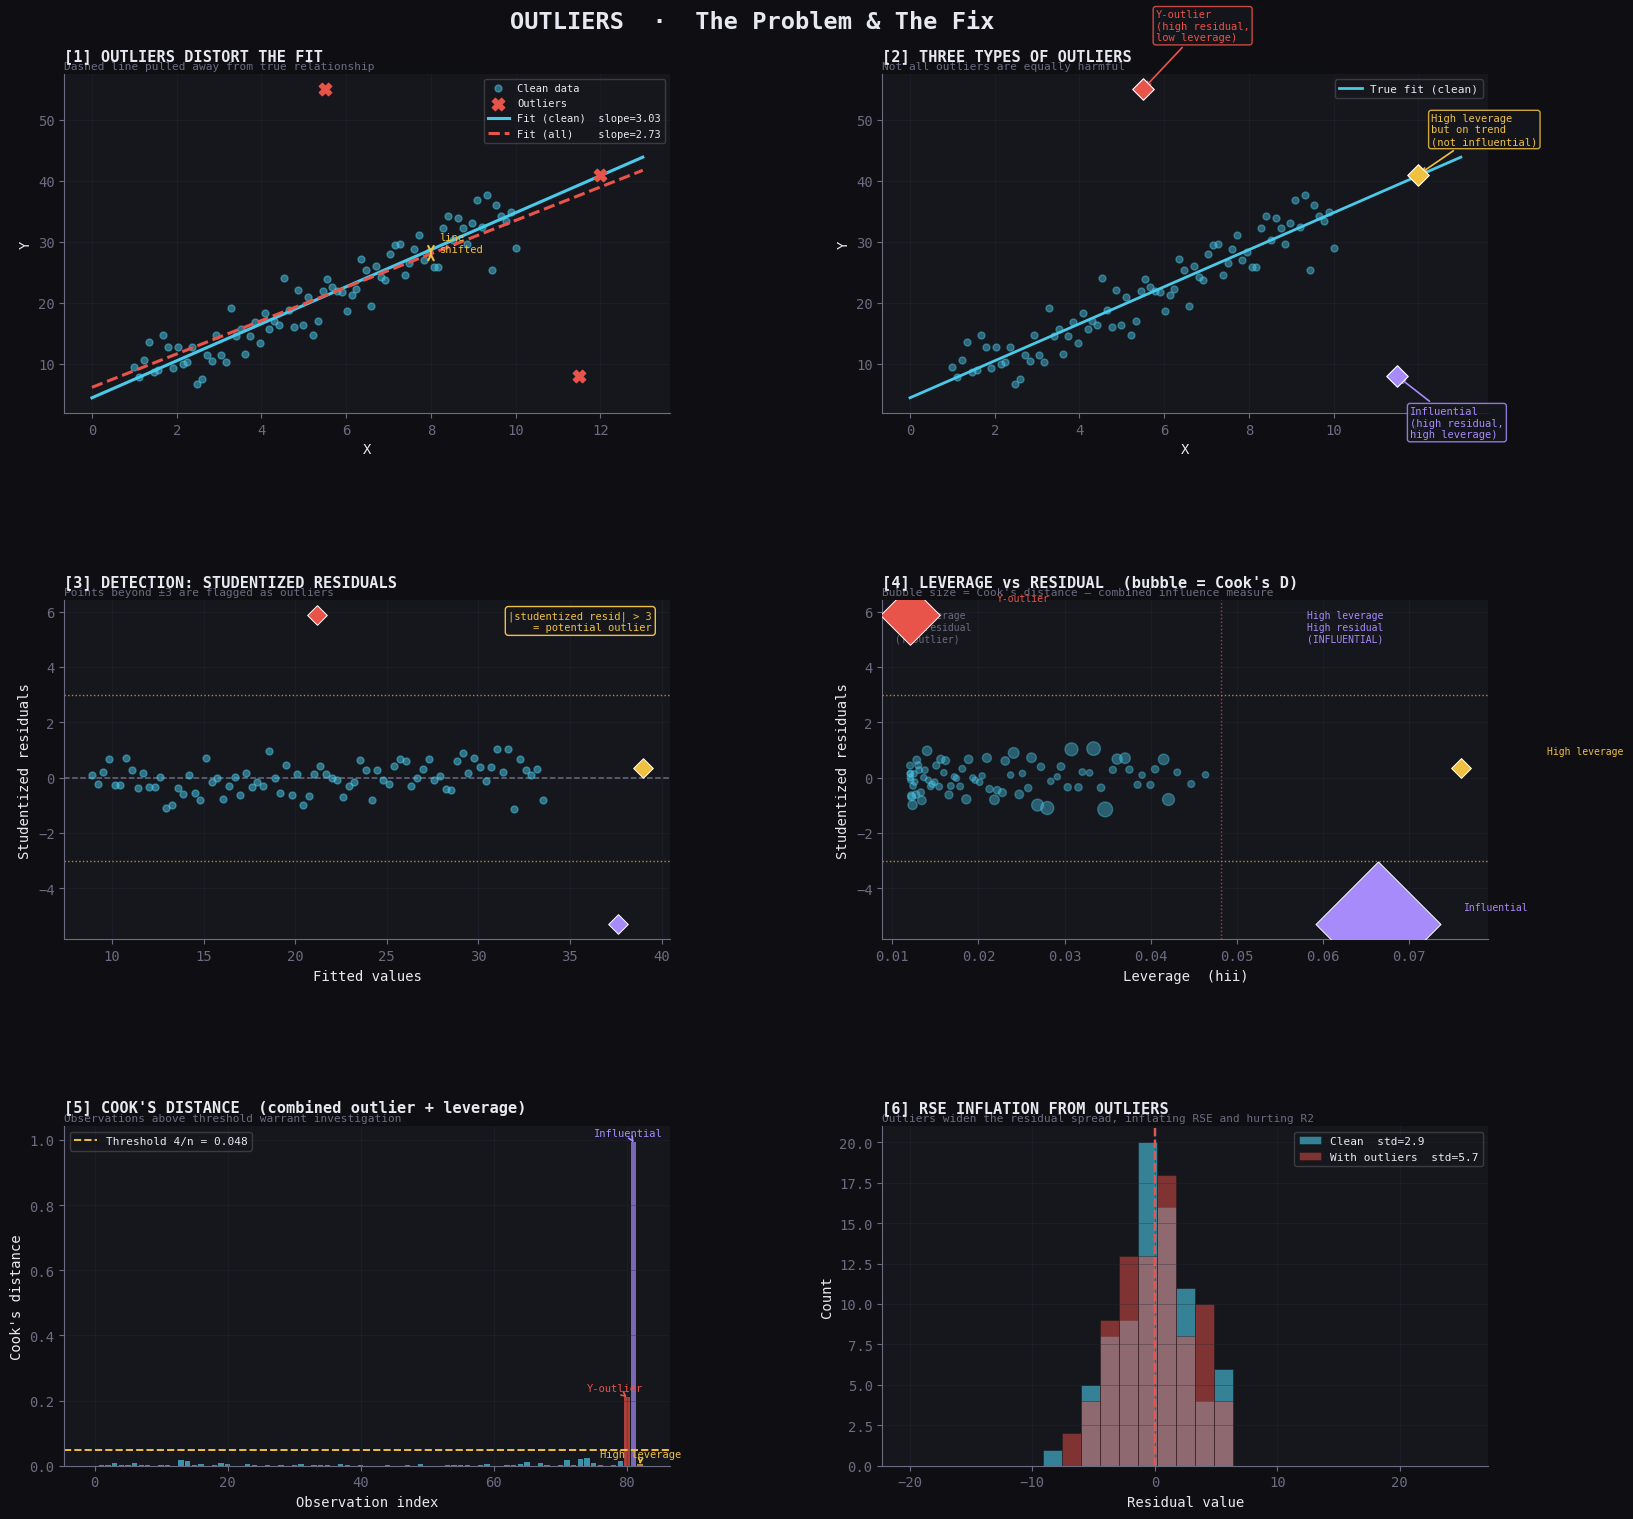

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from scipy import stats

np.random.seed(42)

# ── Palette ──────────────────────────────────────────────────────────────────
BG      = "#0f0f13"
PANEL   = "#16161d"
ACCENT1 = "#e8534a"   # red    – outlier / bad fit
ACCENT2 = "#4ac9e8"   # cyan   – clean data / good fit
ACCENT3 = "#f0c040"   # gold   – highlights / annotations
ACCENT4 = "#a78bfa"   # purple – influential point
TEXT    = "#e8e8f0"
MUTED   = "#6b6b82"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    MUTED,
    "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        TEXT,
    "grid.color":        "#2a2a38",
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Synthetic data ────────────────────────────────────────────────────────────
n       = 80
X_clean = np.linspace(1, 10, n)
Y_clean = 3 * X_clean + 5 + np.random.normal(0, 3, n)

# Three outlier types to illustrate
# (a) Y-outlier: unusual Y, average X  --> large residual, low leverage
# (b) High-leverage + outlier: unusual X AND unusual Y --> influential
# (c) High-leverage, NOT outlier: unusual X but fits the trend --> not influential
outliers_X = np.array([5.5,  11.5,  12.0])
outliers_Y = np.array([55.0,  8.0,  41.0])

X_all = np.concatenate([X_clean, outliers_X])
Y_all = np.concatenate([Y_clean, outliers_Y])
X2d_clean = X_clean.reshape(-1, 1)
X2d_all   = X_all.reshape(-1, 1)

# ── Fit models ────────────────────────────────────────────────────────────────
reg_clean = LinearRegression().fit(X2d_clean, Y_clean)
reg_all   = LinearRegression().fit(X2d_all,   Y_all)

Xplot  = np.linspace(0, 13, 300).reshape(-1, 1)
Y_fit_clean = reg_clean.predict(Xplot)
Y_fit_all   = reg_all.predict(Xplot)

# Studentized residuals (using scipy for full model)
resid_all  = Y_all - reg_all.predict(X2d_all)
n_all      = len(Y_all)
p          = 2   # intercept + slope
MSE        = np.sum(resid_all**2) / (n_all - p)
# Hat matrix diagonal (leverage)
X_mat      = np.column_stack([np.ones(n_all), X_all])
H          = X_mat @ np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T
h          = np.diag(H)
studentized = resid_all / (np.sqrt(MSE * (1 - h)))

# Cook's distance
cooks_d = (studentized**2 / p) * (h / (1 - h))

# indices
outlier_idx = [n, n+1, n+2]   # positions in X_all / Y_all

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 16), facecolor=BG)
fig.suptitle("OUTLIERS  ·  The Problem & The Fix",
             fontsize=17, fontweight="bold", color=TEXT, y=0.97)

gs = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.55, wspace=0.35,
                        left=0.07, right=0.96,
                        top=0.93, bottom=0.06)

ax1 = fig.add_subplot(gs[0, 0])   # scatter: fit with vs without outliers
ax2 = fig.add_subplot(gs[0, 1])   # outlier types annotated
ax3 = fig.add_subplot(gs[1, 0])   # studentized residuals vs fitted
ax4 = fig.add_subplot(gs[1, 1])   # leverage vs studentized residuals (bubble)
ax5 = fig.add_subplot(gs[2, 0])   # Cook's distance bar chart
ax6 = fig.add_subplot(gs[2, 1])   # residual distribution: with vs without

def style_ax(ax, title, subtitle=""):
    ax.set_title(title, fontsize=11, fontweight="bold",
                 color=TEXT, pad=10, loc="left")
    if subtitle:
        ax.text(0.0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=8, color=MUTED)
    ax.grid(True, alpha=0.4)

# ── [1] Scatter: effect of outliers on the regression line ───────────────────
ax1.scatter(X_clean, Y_clean, s=25, color=ACCENT2, alpha=0.5, zorder=2,
            label="Clean data")
ax1.scatter(outliers_X, outliers_Y, s=80, color=ACCENT1, zorder=4,
            marker="X", label="Outliers")
ax1.plot(Xplot, Y_fit_clean, color=ACCENT2, lw=2.2,
         label=f"Fit (clean)  slope={reg_clean.coef_[0]:.2f}")
ax1.plot(Xplot, Y_fit_all,   color=ACCENT1, lw=2.2, ls="--",
         label=f"Fit (all)    slope={reg_all.coef_[0]:.2f}")
ax1.set_xlabel("X"); ax1.set_ylabel("Y")
ax1.legend(fontsize=7.5, framealpha=0.2)
style_ax(ax1, "[1] OUTLIERS DISTORT THE FIT",
         "Dashed line pulled away from true relationship")

# arrow showing line shift
mid_x = 8
ax1.annotate("", xy=(mid_x, reg_all.predict([[mid_x]])[0]),
             xytext=(mid_x, reg_clean.predict([[mid_x]])[0]),
             arrowprops=dict(arrowstyle="<->", color=ACCENT3, lw=1.5))
ax1.text(mid_x + 0.2,
         (reg_all.predict([[mid_x]])[0] + reg_clean.predict([[mid_x]])[0]) / 2,
         "line\nshifted", fontsize=7.5, color=ACCENT3)

# ── [2] Outlier type taxonomy ─────────────────────────────────────────────────
ax2.scatter(X_clean, Y_clean, s=25, color=ACCENT2, alpha=0.45, zorder=2)
ax2.plot(Xplot, Y_fit_clean, color=ACCENT2, lw=2, label="True fit (clean)")

labels   = ["Y-outlier\n(high residual,\nlow leverage)",
            "Influential\n(high residual,\nhigh leverage)",
            "High leverage\nbut on trend\n(not influential)"]
colors   = [ACCENT1, ACCENT4, ACCENT3]
for i, (ox, oy, lbl, col) in enumerate(zip(outliers_X, outliers_Y, labels, colors)):
    ax2.scatter(ox, oy, s=120, color=col, zorder=5, marker="D", edgecolors="white", lw=0.8)
    offset = [(0.3, 8), (0.3, -10), (0.3, 5)][i]
    ax2.annotate(lbl, xy=(ox, oy), xytext=(ox + offset[0], oy + offset[1]),
                 arrowprops=dict(arrowstyle="->", color=col, lw=1.2),
                 fontsize=7.5, color=col,
                 bbox=dict(boxstyle="round,pad=0.25", facecolor=PANEL,
                           edgecolor=col, alpha=0.85))

ax2.set_xlabel("X"); ax2.set_ylabel("Y")
ax2.legend(fontsize=8, framealpha=0.2)
style_ax(ax2, "[2] THREE TYPES OF OUTLIERS",
         "Not all outliers are equally harmful")

# ── [3] Studentized residuals vs fitted ──────────────────────────────────────
yhat_all = reg_all.predict(X2d_all)
colors_s = [ACCENT2] * n + [ACCENT1, ACCENT4, ACCENT3]
ax3.axhline(0,  color=MUTED, lw=1.1, ls="--")
ax3.axhline(3,  color=ACCENT3, lw=1,   ls=":", alpha=0.7)
ax3.axhline(-3, color=ACCENT3, lw=1,   ls=":", alpha=0.7)
ax3.scatter(yhat_all[:-3], studentized[:-3], s=25, color=ACCENT2,
            alpha=0.5, zorder=2, label="Clean points")
for i, idx in enumerate(outlier_idx):
    ax3.scatter(yhat_all[idx], studentized[idx], s=100,
                color=colors_s[idx], zorder=4, marker="D",
                edgecolors="white", lw=0.7)

ax3.text(0.97, 0.97, "|studentized resid| > 3\n= potential outlier",
         transform=ax3.transAxes, ha="right", va="top",
         fontsize=7.5, color=ACCENT3,
         bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL, edgecolor=ACCENT3))
ax3.set_xlabel("Fitted values")
ax3.set_ylabel("Studentized residuals")
style_ax(ax3, "[3] DETECTION: STUDENTIZED RESIDUALS",
         "Points beyond ±3 are flagged as outliers")

# ── [4] Leverage vs studentized residuals (bubble = Cook's D) ────────────────
ax4.axhline(3,  color=ACCENT3, lw=1, ls=":", alpha=0.7)
ax4.axhline(-3, color=ACCENT3, lw=1, ls=":", alpha=0.7)
lev_threshold = 2 * (p) / n_all
ax4.axvline(lev_threshold, color=ACCENT1, lw=1, ls=":", alpha=0.7)

size_scale = cooks_d * 4000 + 20
ax4.scatter(h[:-3], studentized[:-3],
            s=size_scale[:-3], color=ACCENT2, alpha=0.4, zorder=2)
for i, idx in enumerate(outlier_idx):
    ax4.scatter(h[idx], studentized[idx],
                s=size_scale[idx] + 60, color=colors_s[idx],
                zorder=4, marker="D", edgecolors="white", lw=0.7)
    ax4.annotate(labels[i].split("\n")[0],
                 xy=(h[idx], studentized[idx]),
                 xytext=(h[idx] + 0.01, studentized[idx] + 0.5),
                 fontsize=7, color=colors_s[idx])

# quadrant labels
ax4.text(0.02, 0.97, "Low leverage\nHigh residual\n(Y-outlier)",
         transform=ax4.transAxes, va="top", fontsize=7, color=MUTED)
ax4.text(0.70, 0.97, "High leverage\nHigh residual\n(INFLUENTIAL)",
         transform=ax4.transAxes, va="top", fontsize=7, color=ACCENT4)
ax4.set_xlabel("Leverage  (hii)")
ax4.set_ylabel("Studentized residuals")
style_ax(ax4, "[4] LEVERAGE vs RESIDUAL  (bubble = Cook's D)",
         "Bubble size = Cook's distance — combined influence measure")

# ── [5] Cook's distance bar chart ────────────────────────────────────────────
bar_colors = [ACCENT2] * n + [ACCENT1, ACCENT4, ACCENT3]
ax5.bar(range(n_all), cooks_d, color=bar_colors, alpha=0.7, width=0.8)
threshold_cook = 4 / n_all
ax5.axhline(threshold_cook, color=ACCENT3, lw=1.4, ls="--",
            label=f"Threshold 4/n = {threshold_cook:.3f}")
for idx, lbl, col in zip(outlier_idx, labels, [ACCENT1, ACCENT4, ACCENT3]):
    ax5.annotate(lbl.split("\n")[0],
                 xy=(idx, cooks_d[idx]),
                 xytext=(idx - 6, cooks_d[idx] + 0.02),
                 arrowprops=dict(arrowstyle="->", color=col, lw=1.2),
                 fontsize=7.5, color=col)
ax5.set_xlabel("Observation index")
ax5.set_ylabel("Cook's distance")
ax5.legend(fontsize=8, framealpha=0.2)
style_ax(ax5, "[5] COOK'S DISTANCE  (combined outlier + leverage)",
         "Observations above threshold warrant investigation")

# ── [6] Residual distribution: with vs without outliers ──────────────────────
resid_clean = Y_clean - reg_clean.predict(X2d_clean)
bins = np.linspace(-20, 25, 30)
ax6.hist(resid_clean, bins=bins, color=ACCENT2, alpha=0.6,
         edgecolor=BG, lw=0.5, label=f"Clean  std={resid_clean.std():.1f}")
ax6.hist(resid_all,   bins=bins, color=ACCENT1, alpha=0.5,
         edgecolor=BG, lw=0.5, label=f"With outliers  std={resid_all.std():.1f}")
ax6.axvline(resid_clean.mean(), color=ACCENT2, lw=1.6, ls="--")
ax6.axvline(resid_all.mean(),   color=ACCENT1, lw=1.6, ls="--")
ax6.set_xlabel("Residual value")
ax6.set_ylabel("Count")
ax6.legend(fontsize=8, framealpha=0.2)
style_ax(ax6, "[6] RSE INFLATION FROM OUTLIERS",
         "Outliers widen the residual spread, inflating RSE and hurting R2")

out = "/mnt/user-data/outputs/outliers_demo.png"
plt.show()

The outlier plots show different types of outliers within a data set and how to identify them. Additional ways to identify outliers (residuals and cook's distance) are plotted to display how to spot influetial outliers.

## Collinearity
Collinearity occurs when two or more predictor variables are correlated with each other. This occurs when there is an intermediate relationship between the predictor variables. This creates issues with identifying the relationship between individual predictor variables and the response variable, because there is no way to remove the relationship between predictor variables. Collinearity can be identified through a correlation matrix. Often times a variable is dropped when collinearity is identified.

**Question:** In scenarios where there is clear collinearity, is there a benefit to running separate models isolating the collinear response variables?
**Investigated answer:** There are scenarios when this could be beneficial but there are caveats. There is a chance of ommited variable bias, which means seperating the predictor variables could result in a systematic error in the model.

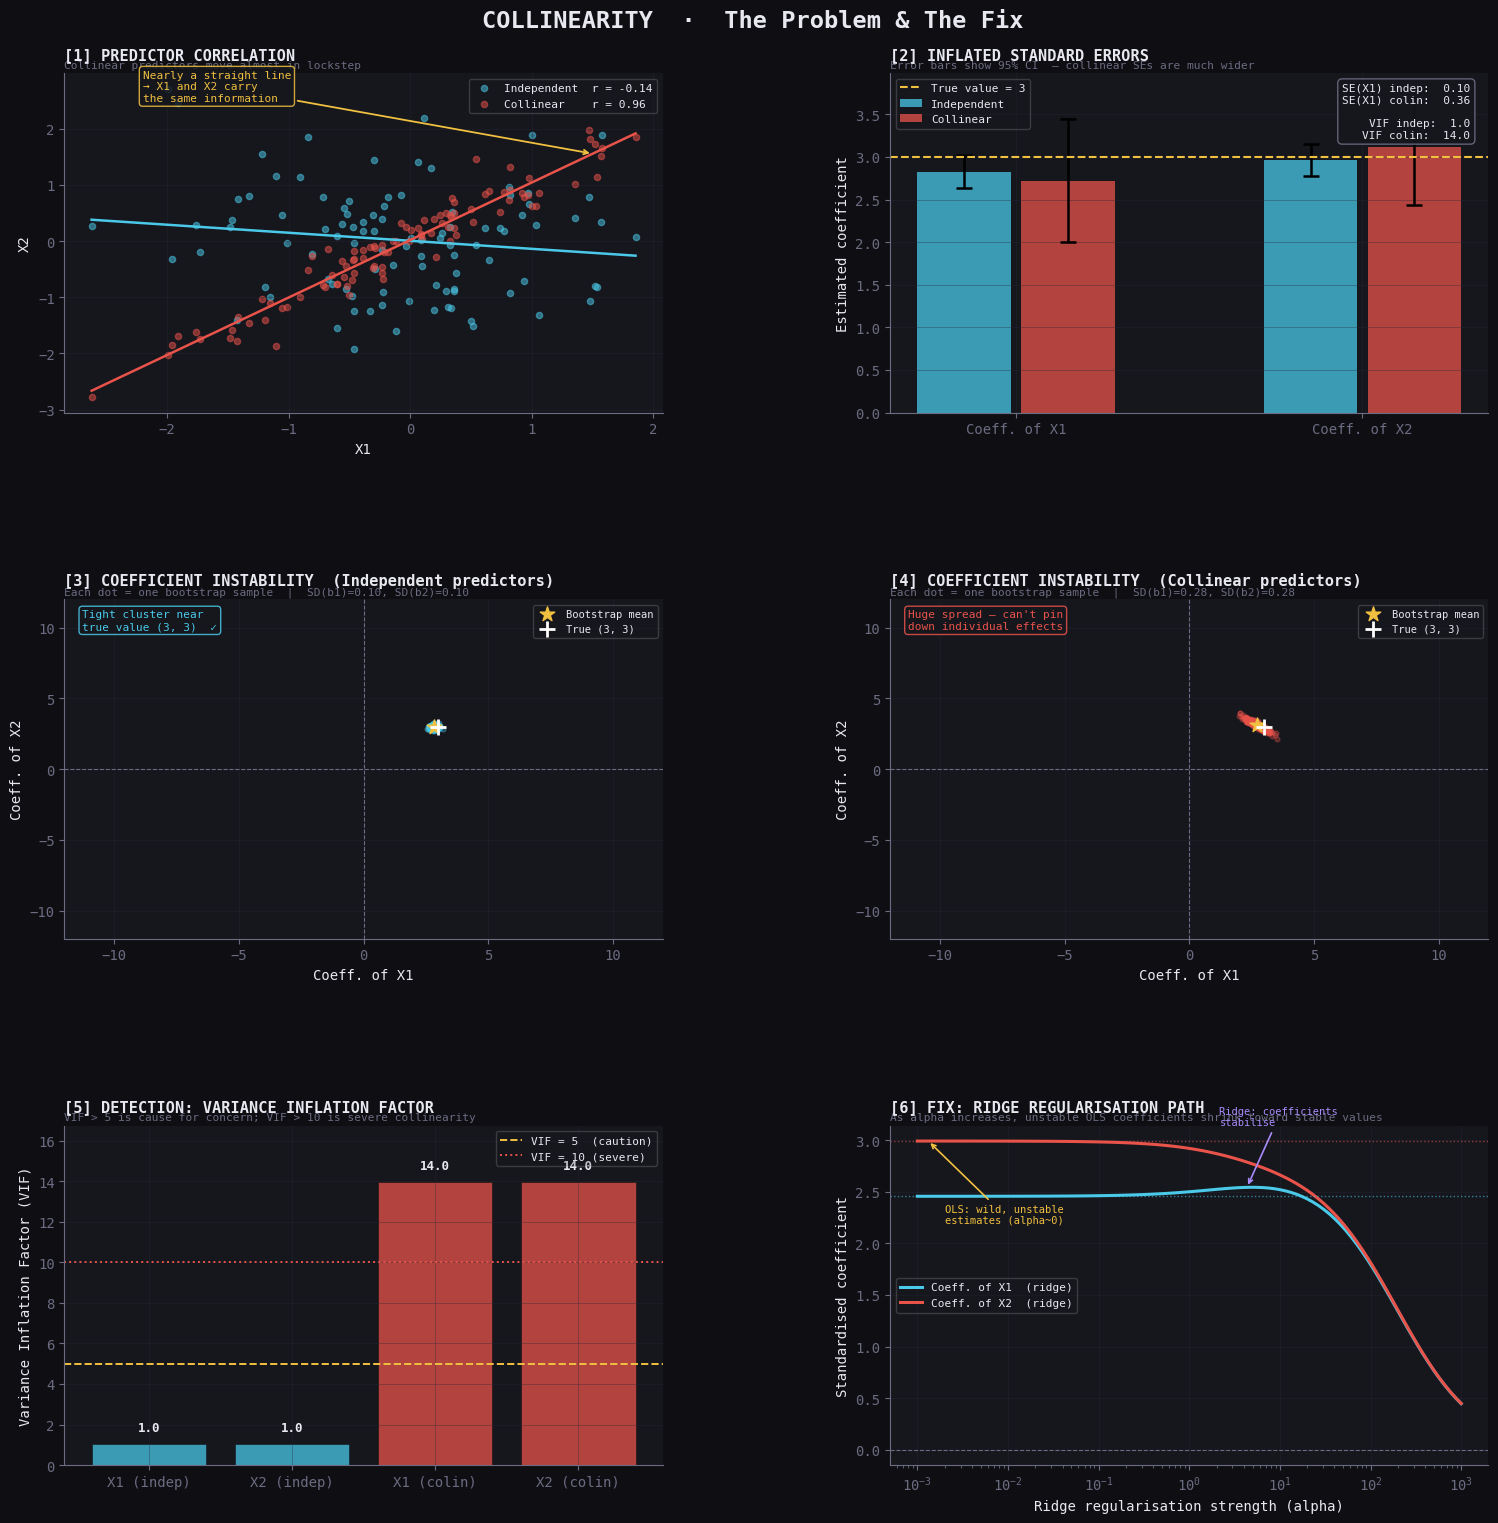

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
import pandas as pd

np.random.seed(42)

# ── Palette ───────────────────────────────────────────────────────────────────
BG      = "#0f0f13"
PANEL   = "#16161d"
ACCENT1 = "#e8534a"   # red    – collinear / bad
ACCENT2 = "#4ac9e8"   # cyan   – independent / good
ACCENT3 = "#f0c040"   # gold   – highlights
ACCENT4 = "#a78bfa"   # purple – ridge / fix
TEXT    = "#e8e8f0"
MUTED   = "#6b6b82"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    MUTED,
    "axes.labelcolor":   TEXT,
    "xtick.color":       MUTED,
    "ytick.color":       MUTED,
    "text.color":        TEXT,
    "grid.color":        "#2a2a38",
    "grid.linewidth":    0.6,
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Synthetic data ────────────────────────────────────────────────────────────
n = 100

# TRUE relationship: Y = 3*X1 + 3*X2 + noise  (coefficients both = 3)
X1 = np.random.normal(0, 1, n)

# Case A: independent predictors
X2_indep = np.random.normal(0, 1, n)

# Case B: highly collinear predictors (r ~ 0.97)
X2_colin = 0.97 * X1 + np.sqrt(1 - 0.97**2) * np.random.normal(0, 1, n)

noise = np.random.normal(0, 1, n)
Y_indep = 3 * X1 + 3 * X2_indep + noise
Y_colin = 3 * X1 + 3 * X2_colin + noise

# Correlation coefficients
r_indep = np.corrcoef(X1, X2_indep)[0, 1]
r_colin = np.corrcoef(X1, X2_colin)[0, 1]

# ── Fit OLS on both datasets ──────────────────────────────────────────────────
def fit_ols(x1, x2, y):
    X = np.column_stack([x1, x2])
    reg = LinearRegression().fit(X, y)
    # Standard errors via (X'X)^-1 * sigma^2
    resid = y - reg.predict(X)
    sigma2 = np.sum(resid**2) / (len(y) - 3)
    XtX_inv = np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(XtX_inv) * sigma2)
    return reg.coef_, se

coef_indep, se_indep = fit_ols(X1, X2_indep, Y_indep)
coef_colin, se_colin = fit_ols(X1, X2_colin, Y_colin)

# ── VIF calculation ───────────────────────────────────────────────────────────
def vif(x1, x2):
    r2 = LinearRegression().fit(x1.reshape(-1,1), x2).score(x1.reshape(-1,1), x2)
    return 1 / (1 - r2)

vif_indep = vif(X1, X2_indep)
vif_colin = vif(X1, X2_colin)

# ── Bootstrap: coefficient instability ───────────────────────────────────────
B = 300
boot_coef_indep = np.zeros((B, 2))
boot_coef_colin = np.zeros((B, 2))

for b in range(B):
    idx = np.random.choice(n, n, replace=True)
    c, _ = fit_ols(X1[idx], X2_indep[idx], Y_indep[idx])
    boot_coef_indep[b] = c
    c, _ = fit_ols(X1[idx], X2_colin[idx], Y_colin[idx])
    boot_coef_colin[b] = c

# ── Ridge path ────────────────────────────────────────────────────────────────
alphas   = np.logspace(-3, 3, 100)
ridge_coefs = []
scaler = StandardScaler()
X_colin_s = scaler.fit_transform(np.column_stack([X1, X2_colin]))
for a in alphas:
    r = Ridge(alpha=a).fit(X_colin_s, Y_colin)
    ridge_coefs.append(r.coef_)
ridge_coefs = np.array(ridge_coefs)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 16), facecolor=BG)
fig.suptitle("COLLINEARITY  ·  The Problem & The Fix",
             fontsize=17, fontweight="bold", color=TEXT, y=0.97)

gs = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.55, wspace=0.38,
                        left=0.07, right=0.96,
                        top=0.93, bottom=0.06)

ax1 = fig.add_subplot(gs[0, 0])   # X1 vs X2: independent vs collinear
ax2 = fig.add_subplot(gs[0, 1])   # coefficient estimates + SE comparison
ax3 = fig.add_subplot(gs[1, 0])   # bootstrap cloud: indep
ax4 = fig.add_subplot(gs[1, 1])   # bootstrap cloud: collinear
ax5 = fig.add_subplot(gs[2, 0])   # VIF bar chart
ax6 = fig.add_subplot(gs[2, 1])   # ridge regularisation path

def style_ax(ax, title, subtitle=""):
    ax.set_title(title, fontsize=11, fontweight="bold",
                 color=TEXT, pad=10, loc="left")
    if subtitle:
        ax.text(0.0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=8, color=MUTED)
    ax.grid(True, alpha=0.4)

# ── [1] Predictor scatter: independent vs collinear ──────────────────────────
ax1.scatter(X1, X2_indep, s=20, color=ACCENT2, alpha=0.5,
            label=f"Independent  r = {r_indep:.2f}")
ax1.scatter(X1, X2_colin, s=20, color=ACCENT1, alpha=0.5,
            label=f"Collinear    r = {r_colin:.2f}")

# fit lines
m_indep = np.polyfit(X1, X2_indep, 1)
m_colin = np.polyfit(X1, X2_colin, 1)
xr = np.linspace(X1.min(), X1.max(), 100)
ax1.plot(xr, np.polyval(m_indep, xr), color=ACCENT2, lw=1.8)
ax1.plot(xr, np.polyval(m_colin, xr), color=ACCENT1, lw=1.8)

ax1.set_xlabel("X1"); ax1.set_ylabel("X2")
ax1.legend(fontsize=8, framealpha=0.2)
style_ax(ax1, "[1] PREDICTOR CORRELATION",
         "Collinear predictors move almost in lockstep")

ax1.annotate("Nearly a straight line\n→ X1 and X2 carry\nthe same information",
             xy=(1.5, m_colin[0]*1.5 + m_colin[1]),
             xytext=(-2.2, 2.5),
             arrowprops=dict(arrowstyle="->", color=ACCENT3, lw=1.3),
             fontsize=8, color=ACCENT3,
             bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL,
                       edgecolor=ACCENT3, alpha=0.85))

# ── [2] Coefficient estimates with error bars ─────────────────────────────────
x_pos   = np.array([0, 1])
width   = 0.3
bar_kw  = dict(capsize=6, elinewidth=1.8, capthick=1.8)

for ax_i, (coef, se, color, label) in enumerate([
    (coef_indep, se_indep, ACCENT2, "Independent"),
    (coef_colin, se_colin, ACCENT1, "Collinear"),
]):
    offset = (ax_i - 0.5) * width
    bars = ax2.bar(x_pos + offset, coef, width=width*0.9,
                   color=color, alpha=0.75, label=label,
                   error_kw=bar_kw)
    ax2.errorbar(x_pos + offset, coef, yerr=2*se,
                 fmt="none", color="white", **bar_kw)

ax2.axhline(3.0, color=ACCENT3, lw=1.5, ls="--", label="True value = 3")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(["Coeff. of X1", "Coeff. of X2"])
ax2.set_ylabel("Estimated coefficient")
ax2.legend(fontsize=8, framealpha=0.2)
style_ax(ax2, "[2] INFLATED STANDARD ERRORS",
         "Error bars show 95% CI  — collinear SEs are much wider")

ax2.text(0.97, 0.97,
         f"SE(X1) indep:  {se_indep[0]:.2f}\n"
         f"SE(X1) colin:  {se_colin[0]:.2f}\n\n"
         f"VIF indep:  {vif_indep:.1f}\n"
         f"VIF colin:  {vif_colin:.1f}",
         transform=ax2.transAxes, ha="right", va="top",
         fontsize=8, color=TEXT, family="monospace",
         bbox=dict(boxstyle="round,pad=0.4", facecolor=PANEL,
                   edgecolor=MUTED, alpha=0.9))

# ── [3] & [4] Bootstrap coefficient clouds ────────────────────────────────────
lim = 12
for ax, boot, color, label, case in [
    (ax3, boot_coef_indep, ACCENT2, "Independent predictors", "indep"),
    (ax4, boot_coef_colin, ACCENT1, "Collinear predictors",   "colin"),
]:
    ax.scatter(boot[:, 0], boot[:, 1], s=12, color=color,
               alpha=0.3, zorder=2)
    # 2-sigma ellipse approximation via scatter of means
    ax.scatter(*boot.mean(axis=0), s=120, color=ACCENT3,
               zorder=5, marker="*", label="Bootstrap mean")
    ax.scatter(3, 3, s=120, color="white", zorder=5,
               marker="+", linewidths=2, label="True (3, 3)")
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("Coeff. of X1"); ax.set_ylabel("Coeff. of X2")
    ax.axhline(0, color=MUTED, lw=0.8, ls="--")
    ax.axvline(0, color=MUTED, lw=0.8, ls="--")
    ax.legend(fontsize=7.5, framealpha=0.2)

    std1, std2 = boot[:, 0].std(), boot[:, 1].std()
    title_num = "[3]" if case == "indep" else "[4]"
    style_ax(ax, f"{title_num} COEFFICIENT INSTABILITY  ({label})",
             f"Each dot = one bootstrap sample  |  "
             f"SD(b1)={std1:.2f}, SD(b2)={std2:.2f}")

    if case == "colin":
        ax.text(0.03, 0.97,
                "Huge spread — can't pin\ndown individual effects",
                transform=ax.transAxes, va="top", fontsize=8,
                color=ACCENT1,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL,
                          edgecolor=ACCENT1, alpha=0.85))
    else:
        ax.text(0.03, 0.97,
                "Tight cluster near\ntrue value (3, 3)  ✓",
                transform=ax.transAxes, va="top", fontsize=8,
                color=ACCENT2,
                bbox=dict(boxstyle="round,pad=0.3", facecolor=PANEL,
                          edgecolor=ACCENT2, alpha=0.85))

# ── [5] VIF bar chart ─────────────────────────────────────────────────────────
predictors = ["X1 (indep)", "X2 (indep)", "X1 (colin)", "X2 (colin)"]
vif_vals   = [vif(X2_indep, X1), vif(X1, X2_indep),
              vif(X2_colin, X1), vif(X1, X2_colin)]
bar_colors = [ACCENT2, ACCENT2, ACCENT1, ACCENT1]

bars = ax5.bar(predictors, vif_vals, color=bar_colors, alpha=0.75,
               edgecolor=BG, linewidth=0.5)
ax5.axhline(5,  color=ACCENT3, lw=1.4, ls="--", label="VIF = 5  (caution)")
ax5.axhline(10, color=ACCENT1, lw=1.4, ls=":",  label="VIF = 10 (severe)")

for bar, val in zip(bars, vif_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", va="bottom", fontsize=9,
             color=TEXT, fontweight="bold")

ax5.set_ylabel("Variance Inflation Factor (VIF)")
ax5.set_ylim(0, max(vif_vals) * 1.2)
ax5.legend(fontsize=8, framealpha=0.2)
style_ax(ax5, "[5] DETECTION: VARIANCE INFLATION FACTOR",
         "VIF > 5 is cause for concern; VIF > 10 is severe collinearity")

# ── [6] Ridge regularisation path ────────────────────────────────────────────
ax6.semilogx(alphas, ridge_coefs[:, 0], color=ACCENT2, lw=2.2,
             label="Coeff. of X1  (ridge)")
ax6.semilogx(alphas, ridge_coefs[:, 1], color=ACCENT1, lw=2.2,
             label="Coeff. of X2  (ridge)")
ax6.axhline(0, color=MUTED, lw=0.8, ls="--")

# OLS estimates (alpha -> 0)
ols_s = LinearRegression().fit(X_colin_s, Y_colin)
ax6.axhline(ols_s.coef_[0], color=ACCENT2, lw=1, ls=":", alpha=0.6)
ax6.axhline(ols_s.coef_[1], color=ACCENT1, lw=1, ls=":", alpha=0.6)

ax6.set_xlabel("Ridge regularisation strength (alpha)")
ax6.set_ylabel("Standardised coefficient")
ax6.legend(fontsize=8, framealpha=0.2)
style_ax(ax6, "[6] FIX: RIDGE REGULARISATION PATH",
         "As alpha increases, unstable OLS coefficients shrink toward stable values")

ax6.annotate("OLS: wild, unstable\nestimates (alpha~0)",
             xy=(alphas[2], ridge_coefs[2, 1]),
             xytext=(alphas[5], ridge_coefs[2, 1] - 0.8),
             arrowprops=dict(arrowstyle="->", color=ACCENT3, lw=1.2),
             fontsize=7.5, color=ACCENT3)

ax6.annotate("Ridge: coefficients\nstabilise",
             xy=(alphas[60], ridge_coefs[60, 0]),
             xytext=(alphas[55], ridge_coefs[60, 0] + 0.6),
             arrowprops=dict(arrowstyle="->", color=ACCENT4, lw=1.2),
             fontsize=7.5, color=ACCENT4)

out = "/mnt/user-data/outputs/collinearity_demo.png"
plt.show()

These plots show collinearity of predictor variables in comparison to the independent variable. This shows how in certain scenarios, collinearity can prevent identifying relationships between individual predictor variables and the response variables.

For this exercise I used Claude to generate plots. I first gave the prompt directly from the website to generate the code for each of the linear regression issues that I chose, however it only produced a PNG, so I had to specific I wanted code I could copy. Overall, claude was able to make figures, however the code failed because it was attempting to save the figures as png to a non-existent file path. I ended up removing the final code that attempted to do this and replaced it with `plt.show()`.